In [3]:
pip install pandas numpy matplotlib openpyxl seaborn

Note: you may need to restart the kernel to use updated packages.


✅ Data loaded successfully.

--- FIRST 5 ROWS ---
   LYLTY_CARD_NBR        DATE  STORE_NBR  TXN_ID  PROD_NBR  \
0            1000  2018-10-17          1       1         5   
1            1002  2018-09-16          1       2        58   
2            1003  2019-03-07          1       3        52   
3            1003  2019-03-08          1       4       106   
4            1004  2018-11-02          1       5        96   

                                PROD_NAME  PROD_QTY  TOT_SALES  PACK_SIZE  \
0  Natural Chip        Compny SeaSalt175g         2        6.0        175   
1   Red Rock Deli Chikn&Garlic Aioli 150g         1        2.7        150   
2   Grain Waves Sour    Cream&Chives 210G         1        3.6        210   
3  Natural ChipCo      Hony Soy Chckn175g         1        3.0        175   
4          WW Original Stacked Chips 160g         1        1.9        160   

        BRAND              LIFESTAGE PREMIUM_CUSTOMER  
0     NATURAL  YOUNG SINGLES/COUPLES          Premium  
1 

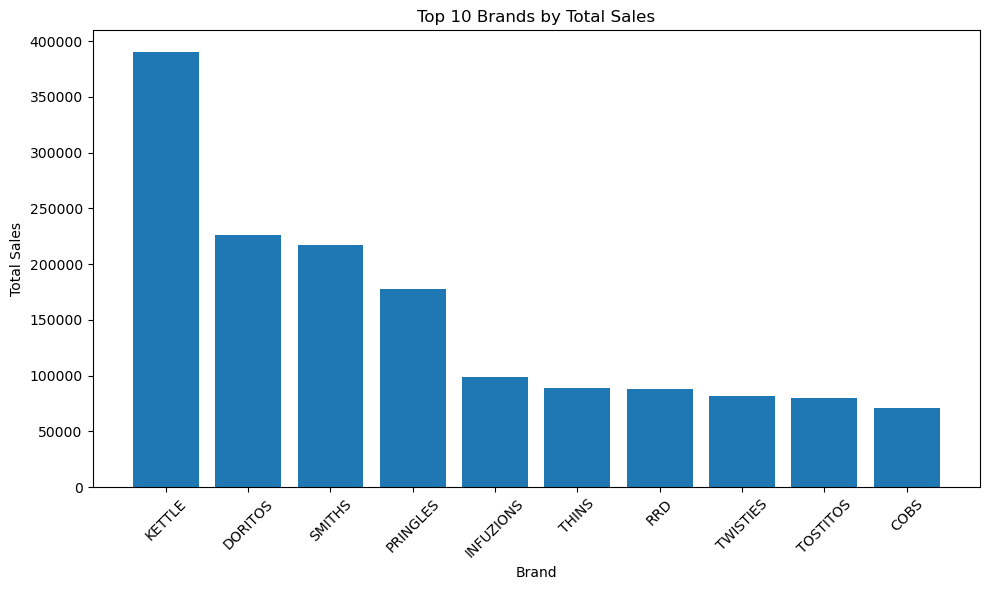

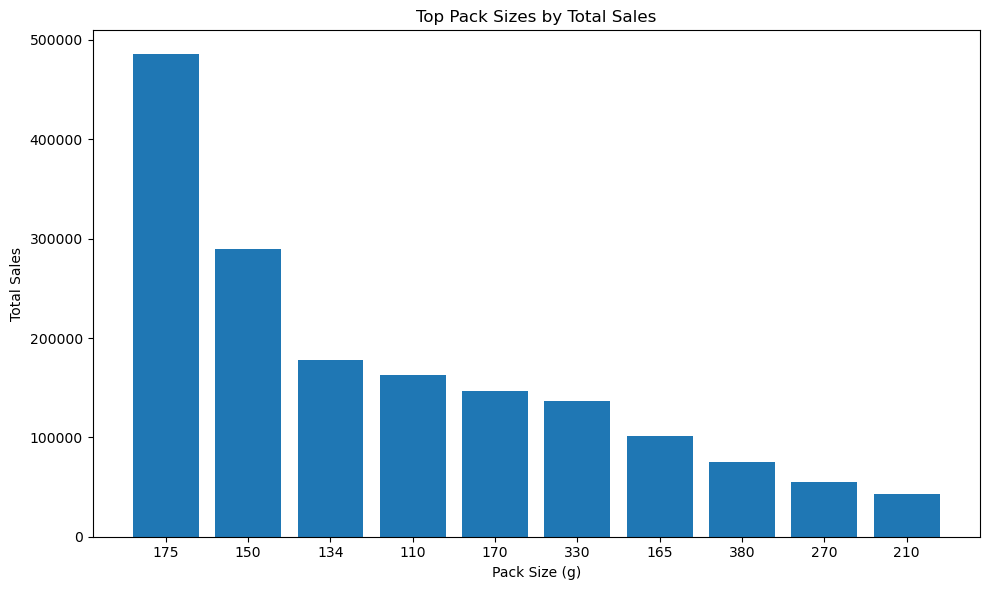

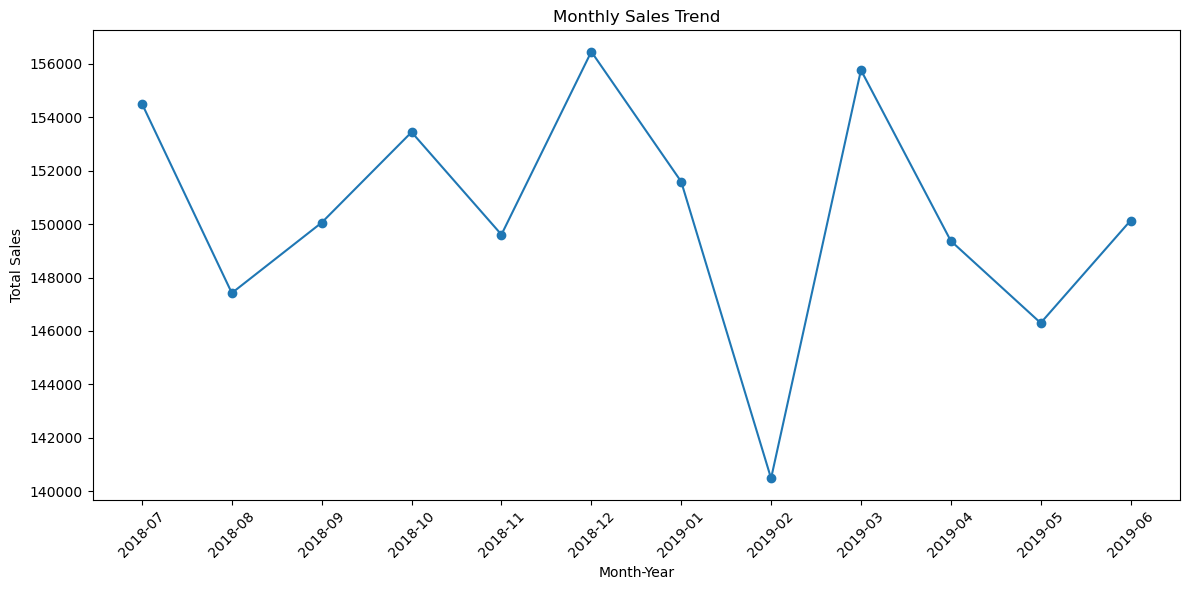

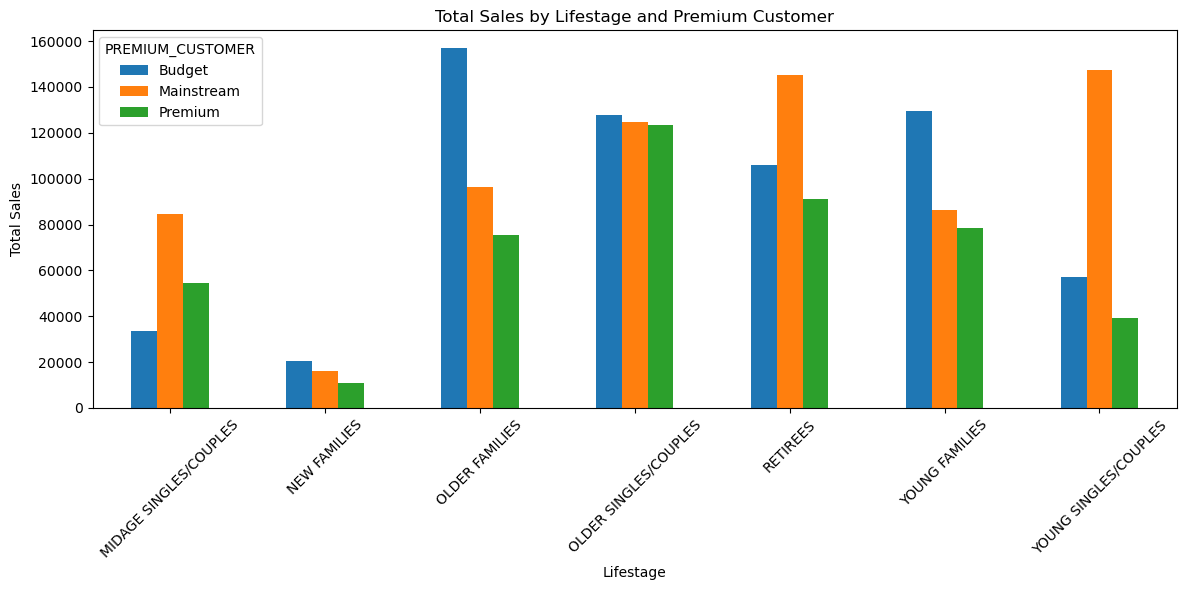


✅ Cleaned data and summary files exported to folder: chips_project_outputs

================ KEY INSIGHTS ================

1. Highest sales segment: OLDER FAMILIES - Budget with total sales of 156863.75.
2. Top-performing brand: KETTLE with total sales of 390239.80.
3. Most popular pack size: 175g with total sales of 485431.40.
4. Average price per unit across all transactions: 3.83.
5. Highest monthly sales were recorded in 2018-12 with total sales of 156461.60.

✅ Project analysis completed successfully.


In [3]:
# CHIPS CUSTOMER PURCHASE ANALYSIS PROJECT
# Full Single-Cell Python Code


import warnings
warnings.filterwarnings("ignore")

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# 1. SETTINGS

FILE_PATH = "C:\\Users\\sahil\\OneDrive\\Documents\\Project\\QVI_data.csv"  
OUTPUT_FOLDER = "chips_project_outputs"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)


# 2. LOAD DATA

try:
    df = pd.read_csv(FILE_PATH)
    print("✅ Data loaded successfully.")
except Exception as e:
    print("❌ Error loading file:", e)
    raise

print("\n--- FIRST 5 ROWS ---")
print(df.head())

print("\n--- SHAPE OF DATA ---")
print(df.shape)

print("\n--- COLUMN NAMES ---")
print(df.columns.tolist())


# 3. BASIC DATA CHECKS

print("\n--- DATA INFO ---")
print(df.info())

print("\n--- MISSING VALUES ---")
print(df.isnull().sum())

print("\n--- DUPLICATE ROWS ---")
print(df.duplicated().sum())

# Drop duplicates
df = df.drop_duplicates()


# 4. STANDARDIZE COLUMN NAMES

df.columns = df.columns.str.strip().str.upper()

# Expected columns in Quantium chips dataset:
# DATE, STORE_NBR, LYLTY_CARD_NBR, TXN_ID, PROD_NBR, PROD_NAME, PROD_QTY, TOT_SALES, LIFESTAGE, PREMIUM_CUSTOMER
# This code is written to handle this dataset structure.

print("\n--- STANDARDIZED COLUMN NAMES ---")
print(df.columns.tolist())


# 5. DATE CONVERSION

# In Quantium dataset, DATE is often Excel serial date.
# We handle both numeric serial date and normal date formats.

if "DATE" in df.columns:
    if pd.api.types.is_numeric_dtype(df["DATE"]):
        try:
            df["DATE"] = pd.to_datetime("1899-12-30") + pd.to_timedelta(df["DATE"], unit="D")
        except:
            df["DATE"] = pd.to_datetime(df["DATE"], errors="coerce")
    else:
        df["DATE"] = pd.to_datetime(df["DATE"], errors="coerce")

# Remove rows with invalid date if DATE exists
if "DATE" in df.columns:
    df = df.dropna(subset=["DATE"])


# 6. DATA TYPE CHECK / CORRECTION

numeric_cols = ["PROD_QTY", "TOT_SALES", "STORE_NBR", "LYLTY_CARD_NBR", "TXN_ID", "PROD_NBR"]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=[col for col in ["PROD_QTY", "TOT_SALES"] if col in df.columns])


# 7. REMOVE INVALID / OUTLIER ROWS

# Remove negative or zero sales / quantity
if "PROD_QTY" in df.columns:
    df = df[df["PROD_QTY"] > 0]

if "TOT_SALES" in df.columns:
    df = df[df["TOT_SALES"] > 0]

# Remove the obvious outlier: commercial quantity purchases
# Common Quantium approach: PROD_QTY < 6
if "PROD_QTY" in df.columns:
    df = df[df["PROD_QTY"] < 6]

# Remove salsa products if user wants chips-only analysis
if "PROD_NAME" in df.columns:
    df = df[~df["PROD_NAME"].str.upper().str.contains("SALSA", na=False)]


# 8. FEATURE ENGINEERING


# Pack Size extraction
def extract_pack_size(product_name):
    if pd.isna(product_name):
        return np.nan
    match = re.search(r'(\d+)\s*[Gg]', str(product_name))
    return int(match.group(1)) if match else np.nan

# Brand extraction
def extract_brand(product_name):
    if pd.isna(product_name):
        return np.nan
    first_word = str(product_name).split()[0].upper()
    
    # Standardize a few common brand spellings
    brand_map = {
        "RED": "RRD",
        "SNBTS": "SUNBITES",
        "INFZNS": "INFUZIONS",
        "WW": "WOOLWORTHS",
        "SMITH": "SMITHS",
        "NCC": "NATURAL",
        "DORITO": "DORITOS",
        "GRAIN": "GRNWVES"
    }
    return brand_map.get(first_word, first_word)

if "PROD_NAME" in df.columns:
    df["PACK_SIZE"] = df["PROD_NAME"].apply(extract_pack_size)
    df["BRAND"] = df["PROD_NAME"].apply(extract_brand)

# Price per unit
if all(col in df.columns for col in ["TOT_SALES", "PROD_QTY"]):
    df["PRICE_PER_UNIT"] = df["TOT_SALES"] / df["PROD_QTY"]

# Year-Month for trend analysis
if "DATE" in df.columns:
    df["MONTH_YEAR"] = df["DATE"].dt.to_period("M").astype(str)


# 9. CLEANED DATA SUMMARY

print("\n--- CLEANED DATA SHAPE ---")
print(df.shape)

print("\n--- CLEANED DATA PREVIEW ---")
print(df.head())

print("\n--- NUMERICAL SUMMARY ---")
print(df.describe(include="all"))


# 10. HIGH-LEVEL FINDINGS TABLES


# Total sales by LIFESTAGE and PREMIUM_CUSTOMER
sales_by_segment = None
if all(col in df.columns for col in ["LIFESTAGE", "PREMIUM_CUSTOMER", "TOT_SALES"]):
    sales_by_segment = (
        df.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"], as_index=False)
          .agg(
              TOTAL_SALES=("TOT_SALES", "sum"),
              TOTAL_QTY=("PROD_QTY", "sum"),
              TRANSACTION_COUNT=("TXN_ID", "nunique") if "TXN_ID" in df.columns else ("TOT_SALES", "count"),
              UNIQUE_CUSTOMERS=("LYLTY_CARD_NBR", "nunique") if "LYLTY_CARD_NBR" in df.columns else ("TOT_SALES", "count")
          )
    )
    
    if "UNIQUE_CUSTOMERS" in sales_by_segment.columns:
        sales_by_segment["AVG_SPEND_PER_CUSTOMER"] = sales_by_segment["TOTAL_SALES"] / sales_by_segment["UNIQUE_CUSTOMERS"]
        sales_by_segment["AVG_QTY_PER_CUSTOMER"] = sales_by_segment["TOTAL_QTY"] / sales_by_segment["UNIQUE_CUSTOMERS"]

# Top brands
top_brands = None
if all(col in df.columns for col in ["BRAND", "TOT_SALES"]):
    top_brands = (
        df.groupby("BRAND", as_index=False)
          .agg(
              TOTAL_SALES=("TOT_SALES", "sum"),
              TOTAL_QTY=("PROD_QTY", "sum")
          )
          .sort_values("TOTAL_SALES", ascending=False)
    )

# Top pack sizes
top_pack_sizes = None
if all(col in df.columns for col in ["PACK_SIZE", "TOT_SALES"]):
    top_pack_sizes = (
        df.groupby("PACK_SIZE", as_index=False)
          .agg(
              TOTAL_SALES=("TOT_SALES", "sum"),
              TOTAL_QTY=("PROD_QTY", "sum")
          )
          .sort_values("TOTAL_SALES", ascending=False)
    )

# Monthly sales
monthly_sales = None
if all(col in df.columns for col in ["MONTH_YEAR", "TOT_SALES"]):
    monthly_sales = (
        df.groupby("MONTH_YEAR", as_index=False)
          .agg(TOTAL_SALES=("TOT_SALES", "sum"))
          .sort_values("MONTH_YEAR")
    )


# 11. DISPLAY KEY TABLES

if sales_by_segment is not None:
    print("\n--- SALES BY CUSTOMER SEGMENT ---")
    print(sales_by_segment.head(20))

if top_brands is not None:
    print("\n--- TOP BRANDS ---")
    print(top_brands.head(10))

if top_pack_sizes is not None:
    print("\n--- TOP PACK SIZES ---")
    print(top_pack_sizes.head(10))

if monthly_sales is not None:
    print("\n--- MONTHLY SALES ---")
    print(monthly_sales.head())


# 12. VISUALIZATIONS


# Chart 1: Top 10 brands by sales
if top_brands is not None and not top_brands.empty:
    plt.figure(figsize=(10, 6))
    plt.bar(top_brands["BRAND"].head(10), top_brands["TOTAL_SALES"].head(10))
    plt.title("Top 10 Brands by Total Sales")
    plt.xlabel("Brand")
    plt.ylabel("Total Sales")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_FOLDER, "top_10_brands_sales.png"), dpi=300)
    plt.show()

# Chart 2: Top 10 pack sizes by sales
if top_pack_sizes is not None and not top_pack_sizes.empty:
    plt.figure(figsize=(10, 6))
    plt.bar(top_pack_sizes["PACK_SIZE"].astype(str).head(10), top_pack_sizes["TOTAL_SALES"].head(10))
    plt.title("Top Pack Sizes by Total Sales")
    plt.xlabel("Pack Size (g)")
    plt.ylabel("Total Sales")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_FOLDER, "top_pack_sizes_sales.png"), dpi=300)
    plt.show()

# Chart 3: Monthly sales trend
if monthly_sales is not None and not monthly_sales.empty:
    plt.figure(figsize=(12, 6))
    plt.plot(monthly_sales["MONTH_YEAR"], monthly_sales["TOTAL_SALES"], marker="o")
    plt.title("Monthly Sales Trend")
    plt.xlabel("Month-Year")
    plt.ylabel("Total Sales")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_FOLDER, "monthly_sales_trend.png"), dpi=300)
    plt.show()

# Chart 4: Total sales by customer segment
if sales_by_segment is not None and not sales_by_segment.empty:
    sales_pivot = sales_by_segment.pivot(index="LIFESTAGE", columns="PREMIUM_CUSTOMER", values="TOTAL_SALES").fillna(0)
    sales_pivot.plot(kind="bar", figsize=(12, 6))
    plt.title("Total Sales by Lifestage and Premium Customer")
    plt.xlabel("Lifestage")
    plt.ylabel("Total Sales")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_FOLDER, "sales_by_segment.png"), dpi=300)
    plt.show()


# 13. EXPORT FILES

df.to_csv(os.path.join(OUTPUT_FOLDER, "cleaned_qvi_data.csv"), index=False)

if sales_by_segment is not None:
    sales_by_segment.to_csv(os.path.join(OUTPUT_FOLDER, "sales_by_segment.csv"), index=False)

if top_brands is not None:
    top_brands.to_csv(os.path.join(OUTPUT_FOLDER, "top_brands.csv"), index=False)

if top_pack_sizes is not None:
    top_pack_sizes.to_csv(os.path.join(OUTPUT_FOLDER, "top_pack_sizes.csv"), index=False)

if monthly_sales is not None:
    monthly_sales.to_csv(os.path.join(OUTPUT_FOLDER, "monthly_sales.csv"), index=False)

# Export everything to one Excel workbook
excel_output = os.path.join(OUTPUT_FOLDER, "chips_analysis_output.xlsx")
with pd.ExcelWriter(excel_output, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="Cleaned_Data", index=False)
    
    if sales_by_segment is not None:
        sales_by_segment.to_excel(writer, sheet_name="Sales_By_Segment", index=False)
    if top_brands is not None:
        top_brands.to_excel(writer, sheet_name="Top_Brands", index=False)
    if top_pack_sizes is not None:
        top_pack_sizes.to_excel(writer, sheet_name="Top_Pack_Sizes", index=False)
    if monthly_sales is not None:
        monthly_sales.to_excel(writer, sheet_name="Monthly_Sales", index=False)

print(f"\n✅ Cleaned data and summary files exported to folder: {OUTPUT_FOLDER}")


# 14. AUTO-GENERATE KEY INSIGHTS

print("\n================ KEY INSIGHTS ================\n")

# Top segment by sales
if sales_by_segment is not None and not sales_by_segment.empty:
    top_segment = sales_by_segment.sort_values("TOTAL_SALES", ascending=False).iloc[0]
    print(f"1. Highest sales segment: {top_segment['LIFESTAGE']} - {top_segment['PREMIUM_CUSTOMER']} "
          f"with total sales of {top_segment['TOTAL_SALES']:.2f}.")

# Top brand
if top_brands is not None and not top_brands.empty:
    best_brand = top_brands.iloc[0]
    print(f"2. Top-performing brand: {best_brand['BRAND']} with total sales of {best_brand['TOTAL_SALES']:.2f}.")

# Top pack size
if top_pack_sizes is not None and not top_pack_sizes.empty:
    best_pack = top_pack_sizes.iloc[0]
    print(f"3. Most popular pack size: {int(best_pack['PACK_SIZE'])}g with total sales of {best_pack['TOTAL_SALES']:.2f}.")

# Avg price per unit
if "PRICE_PER_UNIT" in df.columns:
    print(f"4. Average price per unit across all transactions: {df['PRICE_PER_UNIT'].mean():.2f}.")

# Highest sales month
if monthly_sales is not None and not monthly_sales.empty:
    best_month = monthly_sales.sort_values("TOTAL_SALES", ascending=False).iloc[0]
    print(f"5. Highest monthly sales were recorded in {best_month['MONTH_YEAR']} "
          f"with total sales of {best_month['TOTAL_SALES']:.2f}.")

print("\n✅ Project analysis completed successfully.")